In [1]:
import pandas as pd
import numpy as np

## Дообучение Берта

In [2]:
comments = pd.read_csv('/kaggle/input/datasets/kirill9ko/comments-clean/cleaned_comments.csv')

0) Токенизация текста

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

texts = comments['comment'].astype(str).tolist()

encodings = tokenizer(
    texts,
    padding=False,
    truncation=True,
    max_length=128 
)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [4]:
# ограничение длины комментария по 95му перцентилю
lengths = [len(tokenizer.tokenize(t)) for t in texts]
print(max(lengths))
print(np.percentile(lengths, 95))

460
64.0


1) Проверка что в наших данных нет большого числа неизвестных токенов

In [7]:
unk_id = tokenizer.unk_token_id

total_tokens = 0
unk_tokens = 0

for seq in encodings["input_ids"]:
    total_tokens += len(seq)
    unk_tokens += sum(1 for token in seq if token == unk_id)

unk_ratio = unk_tokens / total_tokens

print(f"Total tokens: {total_tokens}")
print(f"UNK tokens: {unk_tokens}")
print(f"UNK ratio: {unk_ratio:.6f}")

Total tokens: 5352755
UNK tokens: 32740
UNK ratio: 0.006116


In [8]:
bad_examples = []
for text, seq in zip(texts, encodings["input_ids"]):
    if unk_id in seq:
        bad_examples.append(text)
    # я обрезал вывод примеров с плохими токенами, ну в основном это просто смайлики
    if len(bad_examples) > 15:
        break

for t in bad_examples:
    print(t)
    print('-' * 50)

2 августа поздно вечером нашли вот такую потеряшку в районе высоток на победе. девочка явно домашняя, в новом ошейнике. обращаться +7 989 816-43-42
--------------------------------------------------
классно придумано красота👍👍👍
--------------------------------------------------
для вас ,я возьму на себя труд судить о вас ,по-моему большое открытие быть человеком￼ !!!!! если вы с такой беспардонности об этом говорить.
--------------------------------------------------
да это пророк илья пописал!!!😃😃😃
--------------------------------------------------
как здорово! очень, очень рада за вас! 😊👍
--------------------------------------------------
на этих обугленных сковородка картошка была очень вкусная, а если ещё с чесночком👍
--------------------------------------------------
украина территория населенная ублюдками👎
--------------------------------------------------
это же надо так научить!!!👍👍😂😂
--------------------------------------------------
классный сериал клон 👍👍👍👍⭐⭐⭐⭐⭐
----------

Судя по всему о unk токенах можно не переживать, просто смайлики будут игнорироваться 

2. Загрузка модели

In [9]:

label_map = {
    "INSULT" : 0,
    "NORMAL" : 1,
    "THREAT" : 2,
    "OBSCENITY" : 3
}
NUM_LABELS = 4

comments["label"] = comments["label"].map(label_map)

In [10]:
from transformers import AutoModelForSequenceClassification


model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny2",
    num_labels=NUM_LABELS
)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

3. загрузка данных для обучения

In [12]:
import torch
from torch.utils.data import Dataset

# для токенизации текста на лету, будет удобно если будем использовать другие модели и токенайзеры

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
    
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        item["idx"] = idx 
    
        return item


# сразу создаем датасет
dataset = TextDataset(
    texts=comments['comment'].tolist(),
    labels=comments['label'].tolist(),
    tokenizer=tokenizer
)

print("Size:", len(dataset))

Size: 248281


In [13]:
# пример как выглядят данные в датасете
sample = dataset[0]
sample


{'input_ids': tensor([    2, 39969,  2462,     5,  1046, 29861,     3,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

4. дообучение

In [23]:
from torch.utils.data import random_split, DataLoader


total_size = len(dataset)

train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)
test_size  = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)


#  dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
from collections import Counter
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

labels = comments["label"].tolist()
counts = Counter(labels)

num_classes = 4
total = sum(counts.values())

class_weights = [
    total / counts[i] for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([ 8.6915,  1.2190, 21.0819, 58.2682], device='cuda:0')


Train epoch 0: 100%|██████████| 6207/6207 [05:10<00:00, 20.00it/s, loss=0.448] 



Epoch 0
Train loss: 0.5034
Val loss:   0.3688
LR: 0.000020


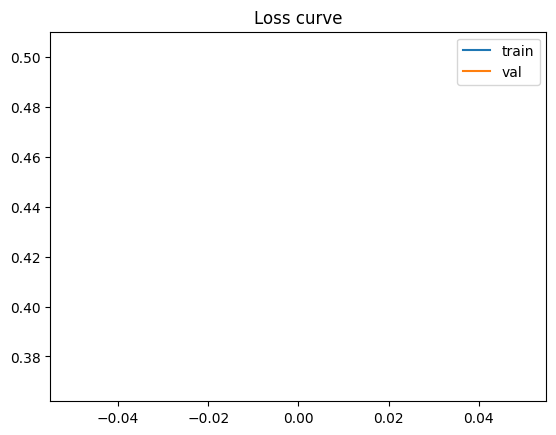

Train epoch 1: 100%|██████████| 6207/6207 [05:14<00:00, 19.75it/s, loss=0.388]  



Epoch 1
Train loss: 0.3281
Val loss:   0.3543
LR: 0.000020


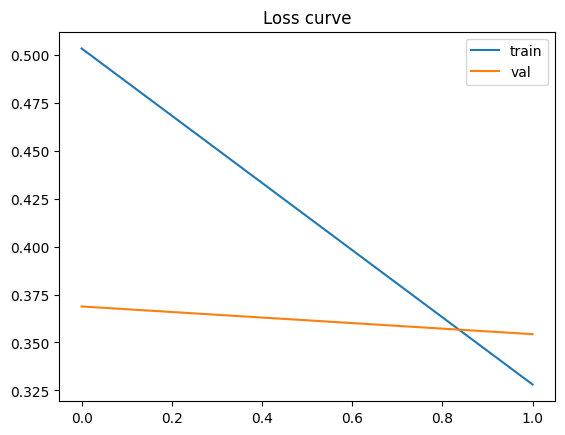

Train epoch 2: 100%|██████████| 6207/6207 [05:24<00:00, 19.11it/s, loss=0.152]  



Epoch 2
Train loss: 0.2707
Val loss:   0.3903
LR: 0.000020


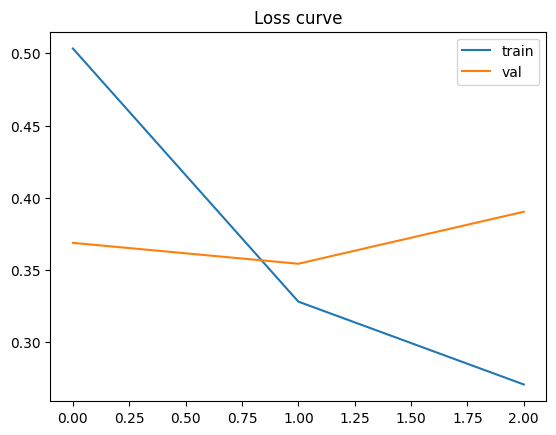

Train epoch 3: 100%|██████████| 6207/6207 [05:21<00:00, 19.33it/s, loss=0.00477] 



Epoch 3
Train loss: 0.2204
Val loss:   0.4360
LR: 0.000020


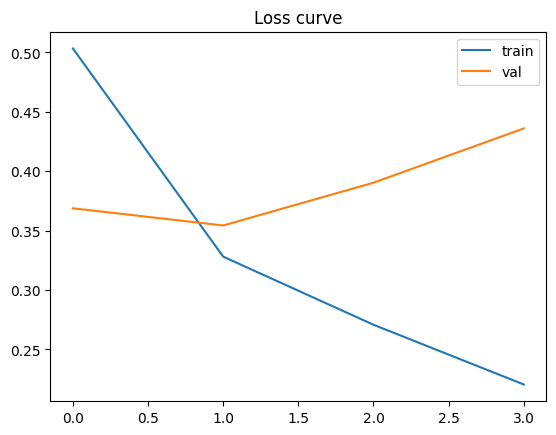

Train epoch 4:   2%|▏         | 98/6207 [00:05<05:12, 19.53it/s, loss=0.0193] 


KeyboardInterrupt: 

In [25]:
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


# Оптимайзер
optimizer = AdamW(model.parameters(), lr=2e-5)

# Scheduler 
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min", 
    factor=0.7,
    patience=3
)


# взвешенный лосс, чтобы у модели не было возможности подстраиваться под наиболее частый класс нрормальных комментариев
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)


train_losses = []
val_losses = []
EPOCHS = 8

for epoch in range(EPOCHS):
    # TRAIN
    model.train()
    total_train_loss = 0

    loop = tqdm(train_loader, desc=f"Train epoch {epoch}")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        
        loss = loss_fn(outputs.logits, batch["labels"])

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        
        # Защита от взрыва градиентов
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        total_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VAL
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )
            loss = loss_fn(outputs.logits, batch["labels"])
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)


    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch}")
    print(f"Train loss: {avg_train_loss:.4f}")
    print(f"Val loss:   {avg_val_loss:.4f}")
    print(f"LR: {current_lr:.6f}")

    # минималистичный график
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.legend()
    plt.title("Loss curve")
    plt.show()

( Я решил остановить обучение после 4х эпох тк модель вроде как переобучается )

In [31]:
import numpy as np

model.eval()

y_true = []
y_pred = []
all_idxs = []

with torch.no_grad():
    for batch in test_loader:
        idxs = batch["idx"]

        batch = {k: v.to(device) for k, v in batch.items() if k != "idx"}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        y_true.extend(batch["labels"].cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        all_idxs.extend(idxs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
all_idxs = np.array(all_idxs)

In [32]:
from sklearn.metrics import classification_report

target_names = [
    "INSULT",
    "NORMAL",
    "THREAT",
    "OBSCENITY"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
))

              precision    recall  f1-score   support

      INSULT     0.8450    0.8873    0.8656      2857
      NORMAL     0.9892    0.9805    0.9848     20373
      THREAT     0.8522    0.8609    0.8565      1179
   OBSCENITY     0.7865    0.8333    0.8092       420

    accuracy                         0.9616     24829
   macro avg     0.8682    0.8905    0.8791     24829
weighted avg     0.9627    0.9616    0.9620     24829



In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 2535   162   107    53]
 [  311 19975    57    30]
 [  114    38  1015    12]
 [   40    18    12   350]]


# Оценка ошибок модели 

из 20 000 тестовых нормальных предложений примерно 200 - токсичные. Интереснее всего посмотреть на них, тк этот тип ошибки может быть наиболее критичен. 

In [39]:
# удобная структура данных, хранит индексы только ошибочно нормальных комментариев
false_normals = all_idxs[(y_pred == 1) & (y_true != 1)].tolist()
fn_texts = [comments.iloc[i]["comment"] for i in false_normals]

print("False normals:", len(false_normals))

False normals: 218


In [66]:
fn_texts[:10]

['бля что за смайлики , пишите отзыва фильма , а не смайлики',
 'благодаря таким людям!!! россия живёт, жила и будит жить!!! и в наше время тоже есть крутые парни. а как этот пидораст👉👌 не обращайте внимание.',
 'недолекий, подлый тип',
 'черен0к 0т флага в задницу и вна украину!',
 'шикарная поза. рачком.',
 'бидло не может вопросы задавать...',
 'а почему её мордой в асфальт не уложили или только с простым людом герои, а перед какой то прошмандовкой в штаны наложили, смотреть противно.',
 'эту кобылу даже рождение ребенка не радует, это просто черт какой то а не человек.',
 'джиго тоже свою родную жену поменял на молодую проститутку и что вышло она же обокрала его чуть не до трусов так и с ним поступят',
 'в троём выехать и не разобрать ис -4 это пипец надо дятлами быть']

Немного выводов:
- Модель все еще ошибается даже в содержательных примерах, например этом: "если я встану - ты ляжешь". Возможно такое можно исправить, если взять модель с большим числом параметров, и собрать больше обучающих данных.
- Модель не успела выучить редкие оскорбительные слова. Например, она не знает кто такие халуи: "у халуев неприкосновенность". Если честно, я тоже не знаю кто это.
- Главный источник ошибок модели - это какие-то, зачастую специальные, орфографические ошибки в оскорбительных словах, или цензурирование матных слов, например пробелами. Такие ошибки закономерны, ведь модель работает на токенах, и получает на вход неправильные токены

In [63]:
# Ошибочно предсказанные оскорбления, которые на самом деле нормальные (лейбл == 1)
false_insults = all_idxs[(y_pred == 0) & (y_true == 1)].tolist()
fi_texts = [comments.iloc[i]["comment"] for i in false_insults]
print("False insults:", len(false_insults))

False insults: 311


In [67]:
fi_texts[:10]

['зч в гдея ей гуготдыхал стобойсне вчервшрива',
 'бездарные безголосые',
 'китайцы уже давно напали только государство оброк им платит лесом.',
 'неприятный гнусавый голос.ничего путного не говорит.живет припеваючи.',
 'свиноматка засмущалась и закрыла лицо ушами',
 '20 лет молчали, а как жареным запахло, начали свою жопу прикрывать.',
 'сволочи, беспредел творят. за освещение событий.',
 'анечка ,вы еще и в мандавошках со знанием дела разбираетесь',
 'он прослезился выступая и обманул народ с тех пор -теперь их дети .правду зная .кричат с другой толпы ты вор ! они привязанные к трону .свой люд не видят с высока - ласкают в золоте корону. как будто это на века . их ожиревшая обслуга как саранча у трона том = и алчность -верная подруга .живёт средь них- с открытым ртом ! байкал природное страданье. с намоленной творцом водой -он людям дан для созиданья в цвет неба сине- голубой !! им руки надо отрубать кто на природу там польстился =байкал не должен увядать он просто малость утомился .

Выводы:
- Иногда оскорбительные слова используются без цели кого-то оскорбить, что, видимо, путает модель. Как, например, в этом предложении - "а чем вам эта жопа не нравится? красивая жопа!!"
- в данных есть предложения, которые действительно скорее оскорбительны, но разметчики посчитали их нормальными, НАпример - "бездарные безголосые" можно считать оскорбительным, что модель и сделала. Это несовершенство разметки,как кажется, основной источник неправильной классификации